Loading training data...

--- Starting 5-Fold Cross-Validation ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:33] WARN


      CROSS-VALIDATION RESULTS (5 Folds)
Mean AUC:       0.7249 (+/- 0.0623)
Mean Accuracy:  0.6691
Mean Precision: 0.5411
Mean Recall:    0.6604
Mean F1-Score:  0.5944

Generating Cross-Validation ROC Plot...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:42:35] WARN

✅ Saved ROC Plot to /Users/maneeshkoti/Documents/ecommerce-churn-prediction/reports/figures/05_cv_roc_curve.png
✅ Saved raw CV results to /Users/maneeshkoti/Documents/ecommerce-churn-prediction/reports/cv_results.csv


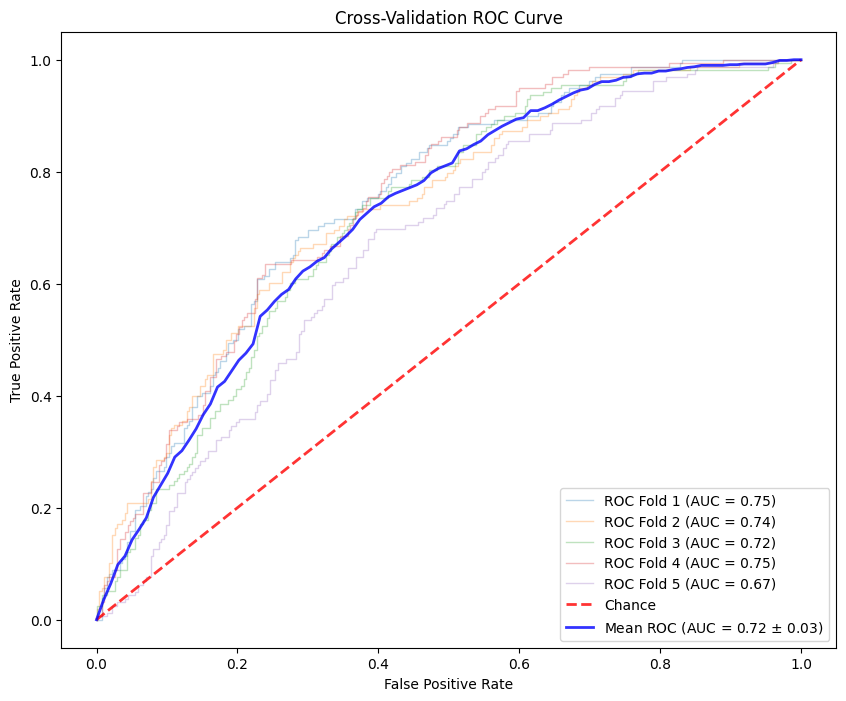

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import roc_curve, auc, make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb

# --- CONFIGURATION ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- LOAD DATA ---
print("Loading training data...")
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv')).values.ravel()

# --- RECONSTRUCT MODEL ---
# We rebuild the Voting Classifier structure to test it fresh
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=4, class_weight='balanced', random_state=42)
xgb_mod = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, 
                            gamma=1, scale_pos_weight=scale_pos, eval_metric='logloss', use_label_encoder=False, random_state=42)

model = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb_mod)], voting='soft')

# --- CROSS-VALIDATION ---
print("\n--- Starting 5-Fold Cross-Validation ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# --- REPORT RESULTS ---
print("\n" + "="*40)
print("      CROSS-VALIDATION RESULTS (5 Folds)")
print("="*40)
print(f"Mean AUC:       {scores['test_roc_auc'].mean():.4f} (+/- {scores['test_roc_auc'].std() * 2:.4f})")
print(f"Mean Accuracy:  {scores['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {scores['test_precision'].mean():.4f}")
print(f"Mean Recall:    {scores['test_recall'].mean():.4f}")
print(f"Mean F1-Score:  {scores['test_f1'].mean():.4f}")
print("="*40)

# --- VISUALIZE ROC CURVES ---
print("\nGenerating Cross-Validation ROC Plot...")
plt.figure(figsize=(10, 8))

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for i, (train, test) in enumerate(cv.split(X_train, y_train)):
    model.fit(X_train.iloc[train], y_train[train])
    y_probas = model.predict_proba(X_train.iloc[test])[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_train[test], y_probas)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation ROC Curve')
plt.legend(loc="lower right")

save_path = os.path.join(FIGURES_DIR, '05_cv_roc_curve.png')
plt.savefig(save_path)
print(f"✅ Saved ROC Plot to {save_path}")

# --- SAVE METRICS TO FILE ---
results_df = pd.DataFrame(scores)
results_path = os.path.join(PROJECT_ROOT, 'reports', 'cv_results.csv')
results_df.to_csv(results_path, index=False)
print(f"✅ Saved raw CV results to {results_path}")